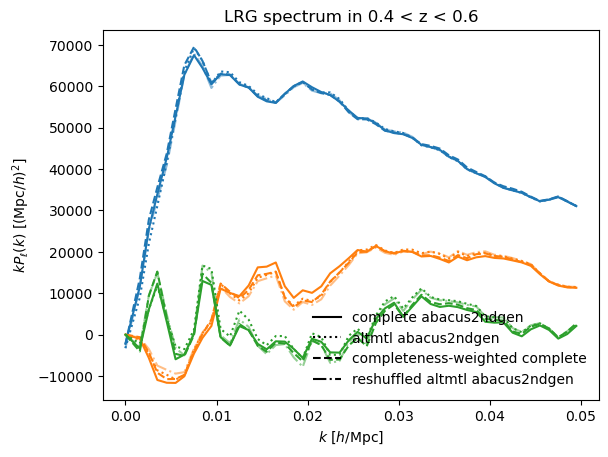

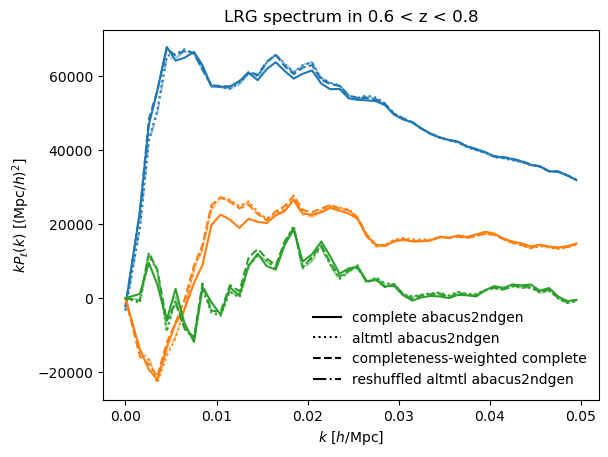

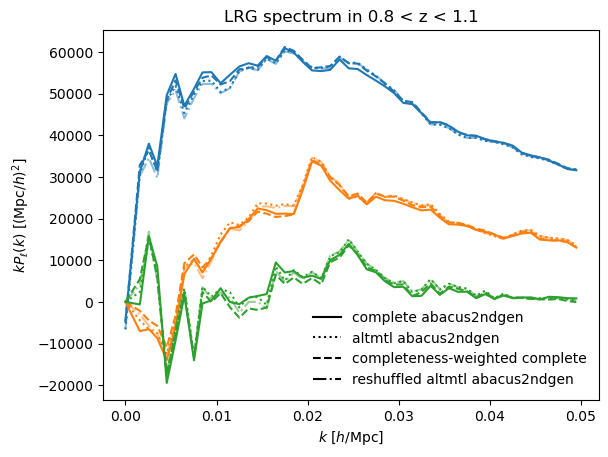

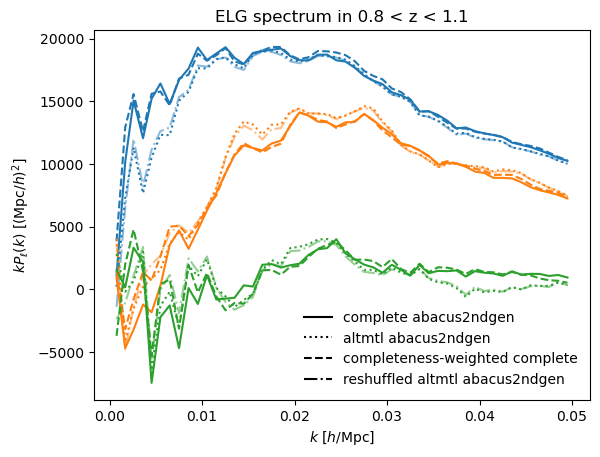

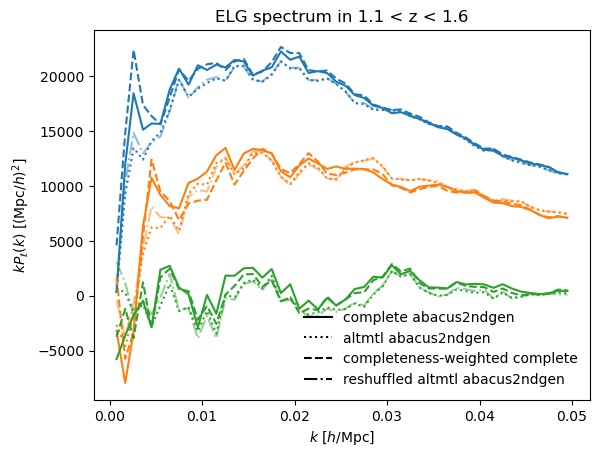

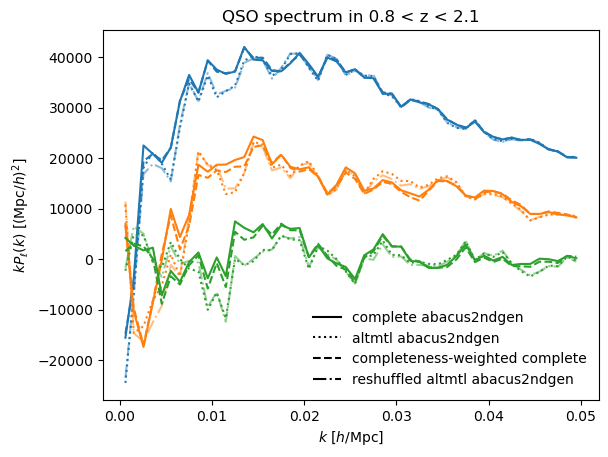

In [1]:
from pathlib import Path

import numpy as np
from matplotlib import pyplot as plt

import lsstypes as types
import sys
sys.path.insert(0, '../../')
from clustering_statistics import tools, box_tools

stats_dir = Path('/dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/desipipe')

kind = 'mesh2_spectrum'
nmocks = 3
region = 'NGC'
weight = 'default-FKP'

for tracer in ['LRG', 'ELG', 'QSO']:
    for zrange in tools.propose_fiducial('zranges', tracer):

        def get_fns(version, extra=''):
            return [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, version=version, tracer=tools.get_full_tracer(tracer, version=version),
                                      zrange=zrange, region=region, weight=weight, imock=imock, extra=extra) for imock in range(nmocks)]

        fns = get_fns(version='abacus-2ndgen-complete')
        mean_complete = types.mean([types.read(fn) for fn in fns])
        fns = get_fns(version='abacus-2ndgen-altmtl')
        mean_altmtl = types.mean([types.read(fn) for fn in fns])
        fns = get_fns(version='abacus-2ndgen-altmtl', extra='complete')
        mean_altmtl_complete = types.mean([types.read(fn) for fn in fns])
        fns = get_fns(version='abacus-2ndgen-altmtl', extra='reshuffle')
        mean_altmtl_reshuffle = types.mean([types.read(fn) for fn in fns])
        
        mean_complete = mean_complete.select(k=slice(0, None, 1)).select(k=(0., 0.05))
        mean_altmtl = mean_altmtl.match(mean_complete)
        mean_altmtl_complete = mean_altmtl_complete.match(mean_complete)
        mean_altmtl_reshuffle = mean_altmtl_reshuffle.match(mean_complete)
        
        fig, ax = plt.subplots()
        ax.set_title(f'{tracer} spectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
        kpow = 0
        for ill, ell in enumerate(mean_complete.ells):
            color = f'C{ill:d}'
            pole = mean_complete.get(ell)
            ax.plot(k:=pole.coords('k'), k**kpow * pole.value(), color=color, linestyle='-')
            pole = mean_altmtl.get(ell)
            ax.plot(k:=pole.coords('k'), k**kpow * pole.value(), color=color, linestyle=':')
            pole = mean_altmtl_complete.get(ell)
            ax.plot(k:=pole.coords('k'), k**kpow * pole.value(), color=color, linestyle='--')
            pole = mean_altmtl_reshuffle.get(ell)
            ax.plot(k:=pole.coords('k'), k**kpow * pole.value(), color=color, linestyle='-.', alpha=0.5)
        ax.plot([], [], color='k', linestyle='-', label='complete abacus2ndgen')
        ax.plot([], [], color='k', linestyle=':', label='altmtl abacus2ndgen')
        ax.plot([], [], color='k', linestyle='--', label='completeness-weighted complete')
        ax.plot([], [], color='k', linestyle='-.', label='reshuffled altmtl abacus2ndgen')
        ax.set_ylabel(rf'$k P_\ell(k)$ [$(\mathrm{{Mpc}}/h)^2$]')
        ax.set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
        ax.legend(frameon=False, loc=4)
        plt.show()